# Train the two missing U-Tikhonov ablations

This notebook completes the $2\times2$ U-Tikhonov experiment.
The two existing runs are left untouched:

| Upper bound | CG 32 | CG 64 |
|---|---|---|
| $4\lambda^*$ | Existing x4/CG32 | **Train x4/CG64 here** |
| $16\lambda^*$ | **Train x16/CG32 here** | Existing x16/CG64 |

The two new runs isolate one factor at a time:

- x16/CG32 versus x4/CG32 measures the effect of increasing
  $\lambda_{\max}$ while solver depth stays fixed.
- x4/CG64 versus x4/CG32 measures the effect of increasing CG depth
  while the lambda range stays fixed.

All other settings remain identical to the existing U-Tikhonov
experiments: SeaTurtle split, U-Net architecture, optimizer,
20 epochs, stochastic training noise, deterministic
$\sigma=0.1$ validation noise, seed, and scalar-reference
initialization.

Completed runs are detected from their checkpoint, full history,
and training summary. They are skipped by default, so rerunning the
notebook does not retrain a finished model.


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def locate_project_root() -> Path:
    """Find cleaned_pipeline regardless of where Jupyter was launched."""
    cwd = Path.cwd().resolve()
    candidates = []
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "cleaned_pipeline"))
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find cleaned_pipeline. Start Jupyter from Thesis/Python, "
        "cleaned_pipeline, or cleaned_pipeline/notebooks."
    )


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline


In [2]:
from argparse import Namespace
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from scripts.train_u_tikhonov import (
    load_reference_lambda,
    train_u_tikhonov,
)
from src.evaluation.benchmark import load_project_model
from src.models.cg_tikhonov import weighted_tikhonov_operator
from src.solvers.conjugate_gradient import cg_solve_until_converged
from src.training.denoising import (
    build_seaturtle_loaders,
    get_device,
)
from src.utils.metrics import batch_psnr, batch_ssim

device = get_device()
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.12.0
Device: mps


## Paths and scalar reference

The scalar $\lambda^*$ is read from Notebook 02. This preserves
the exact reference used by the existing x4/CG32 and x16/CG64
checkpoints.

Edit `SEA_TURTLE_ROOT` to your own SeaTurtle images path.


In [3]:
SEA_TURTLE_ROOT = Path(
    "/Users/kyrillguba/.cache/kagglehub/datasets/"
    "wildlifedatasets/seaturtleid2022/versions/4"
).expanduser()
SCALAR_SUMMARY_PATH = (
    PROJECT_ROOT
    / "results"
    / "tikhonov"
    / "scalar_tikhonov_baseline_summary.csv"
)

if not SEA_TURTLE_ROOT.is_dir():
    raise FileNotFoundError(
        f"SeaTurtle root not found: {SEA_TURTLE_ROOT}. "
        "Edit SEA_TURTLE_ROOT before continuing."
    )
if not SCALAR_SUMMARY_PATH.is_file():
    raise FileNotFoundError(
        f"Missing scalar baseline: {SCALAR_SUMMARY_PATH}. "
        "Run Notebook 03 first."
    )

scalar_summary = pd.read_csv(SCALAR_SUMMARY_PATH)
reference_lambda = float(
    load_reference_lambda(SCALAR_SUMMARY_PATH)
)

print("Reference scalar lambda:", reference_lambda)
display(scalar_summary)


Reference scalar lambda: 2.080083823051904


,best_scalar_lambda,validation_mse,validation_psnr,validation_ssim,average_converged_cg_iters,minimum_converged_cg_iters,maximum_converged_cg_iters,recommended_fixed_cg_iters,validation_sigma,validation_noise_seed
0,2.080084,0.001103,29.932832,0.775427,26.44,25,28,32,0.1,10000


## Define only the two missing experiments
Defines the x16/CG32 and x4/CG64 experiments together with their shared epochs, bounds, stopping tolerance, and completed-run policy.

In [4]:
EXPERIMENTS = OrderedDict(
    [
        (
            "U-Tikhonov x16 CG32",
            {
                "lambda_multiplier": 16.0,
                "cg_iters": 32,
                "run_name": "u_tikhonov_bounded_x16_cg32",
            },
        ),
        (
            "U-Tikhonov x4 CG64",
            {
                "lambda_multiplier": 4.0,
                "cg_iters": 64,
                "run_name": "u_tikhonov_bounded_x4_cg64",
            },
        ),
    ]
)

SKIP_COMPLETED_RUNS = True
EPOCHS = 20
LAMBDA_MIN = 1e-4

experiment_table = pd.DataFrame(
    [
        {
            "method": method,
            "checkpoint_directory": (
                PROJECT_ROOT
                / "checkpoints"
                / spec["run_name"]
            ),
            "lambda_max_multiplier": spec["lambda_multiplier"],
            "lambda_max": (
                spec["lambda_multiplier"] * reference_lambda
            ),
            "cg_iterations": spec["cg_iters"],
        }
        for method, spec in EXPERIMENTS.items()
    ]
)
display(experiment_table)


,method,checkpoint_directory,lambda_max_multiplier,lambda_max,cg_iterations
0,U-Tikhonov x16 CG32,/Users/kyrillguba/Documents/Data Analytics MSc...,16.0,33.281341,32
1,U-Tikhonov x4 CG64,/Users/kyrillguba/Documents/Data Analytics MSc...,4.0,8.320335,64


Defines helpers that build matched training arguments, detect completed runs, and identify incomplete checkpoint directories before training begins.

In [5]:
def make_args(spec):
    checkpoint_dir = (
        PROJECT_ROOT / "checkpoints" / spec["run_name"]
    )
    return Namespace(
        data_root=str(SEA_TURTLE_ROOT),
        checkpoint_dir=str(checkpoint_dir),

        image_size=256,
        max_images=550,
        val_images=50,

        # These match the already-trained U-Tikhonov runs.
        sigma_min=0.0,
        sigma_max=0.2,
        val_sigma=0.1,
        val_noise_seed=10_000,

        base_channels=32,
        depth=3,

        cg_iters=int(spec["cg_iters"]),
        cg_relative_tol=1e-7,

        reference_lambda=reference_lambda,
        scalar_baseline_summary=str(SCALAR_SUMMARY_PATH),
        map_scale=None,

        lambda_parameterization="bounded_sigmoid",
        lambda_min=LAMBDA_MIN,
        lambda_max=float(
            spec["lambda_multiplier"] * reference_lambda
        ),

        epochs=EPOCHS,
        batch_size=1,
        lr=1e-4,
        weight_decay=1e-5,
        grad_clip=1.0,

        num_workers=0,
        print_every=50,
        seed=42,
        device=None,
        clamp_for_metrics=True,
    )


def completed_run(checkpoint_dir: Path, epochs: int) -> bool:
    checkpoint = checkpoint_dir / "u_tikhonov_best.pth"
    history_path = checkpoint_dir / "history.csv"
    summary_path = checkpoint_dir / "training_summary.csv"
    if not (
        checkpoint.is_file()
        and history_path.is_file()
        and summary_path.is_file()
    ):
        return False
    history = pd.read_csv(history_path)
    return len(history) >= epochs


def incomplete_run_files(checkpoint_dir: Path) -> list[Path]:
    if not checkpoint_dir.is_dir():
        return []
    return [
        path
        for path in checkpoint_dir.iterdir()
        if path.is_file()
    ]


## Train the missing runs

The models train sequentially. Each gets a freshly constructed
loader and the same seed, split, and noise settings. If a run was
interrupted and its directory contains partial files, the cell
stops instead of silently mixing old and new outputs.


In [6]:
trained_models = OrderedDict()
run_histories = OrderedDict()
run_loaders = {}

for method, spec in EXPERIMENTS.items():
    args = make_args(spec)
    checkpoint_dir = Path(args.checkpoint_dir)
    train_loader, val_loader = build_seaturtle_loaders(args)

    assert len(train_loader.dataset) == 500
    assert len(val_loader.dataset) == 50
    assert np.isclose(
        float(val_loader.dataset[0]["sigma"]),
        args.val_sigma,
    )

    if SKIP_COMPLETED_RUNS and completed_run(
        checkpoint_dir,
        args.epochs,
    ):
        print(f"\nSkipping completed run: {method}")
        model, _ = load_project_model(
            checkpoint_dir / "u_tikhonov_best.pth",
            device,
        )
        history = pd.read_csv(checkpoint_dir / "history.csv")
    else:
        partial_files = incomplete_run_files(checkpoint_dir)
        if partial_files:
            raise FileExistsError(
                f"{method} has an incomplete/non-empty run "
                f"directory: {checkpoint_dir}. Move or rename that "
                "directory before restarting this run."
            )
        print(f"\nTraining: {method}")
        model, history = train_u_tikhonov(
            args,
            train_loader=train_loader,
            val_loader=val_loader,
        )

    model.eval()
    trained_models[method] = model
    run_histories[method] = history
    run_loaders[method] = val_loader

print("\nReady models:", list(trained_models))



Training: U-Tikhonov x16 CG32
Using device: mps
Model: u_tikhonov | train images: 500 | validation images: 50
Epoch 001 | batch 0050/0500 | train MSE 1.958152e-03
Epoch 001 | batch 0100/0500 | train MSE 6.435108e-04
Epoch 001 | batch 0150/0500 | train MSE 1.457181e-04
Epoch 001 | batch 0200/0500 | train MSE 1.717404e-03
Epoch 001 | batch 0250/0500 | train MSE 2.393768e-03
Epoch 001 | batch 0300/0500 | train MSE 1.391148e-03
Epoch 001 | batch 0350/0500 | train MSE 2.201921e-03
Epoch 001 | batch 0400/0500 | train MSE 1.104022e-03
Epoch 001 | batch 0450/0500 | train MSE 1.373187e-03
Epoch 001 | batch 0500/0500 | train MSE 3.291636e-03
Epoch 001 | train MSE 1.228823e-03 | val MSE 1.132845e-03 | val PSNR 29.972 | val SSIM 0.7950 | noisy PSNR 20.137 | saved best
Epoch 002 | batch 0050/0500 | train MSE 1.363503e-03
Epoch 002 | batch 0100/0500 | train MSE 8.020446e-04
Epoch 002 | batch 0150/0500 | train MSE 1.170303e-03
Epoch 002 | batch 0200/0500 | train MSE 1.334741e-03
Epoch 002 | batch 02

## Compare the two new training runs
Plots MSE, validation quality, and learned lambda-map trajectories for each ablation run, and combines each run's saved training summary with its bound and solver settings, to display a unified comparison table.


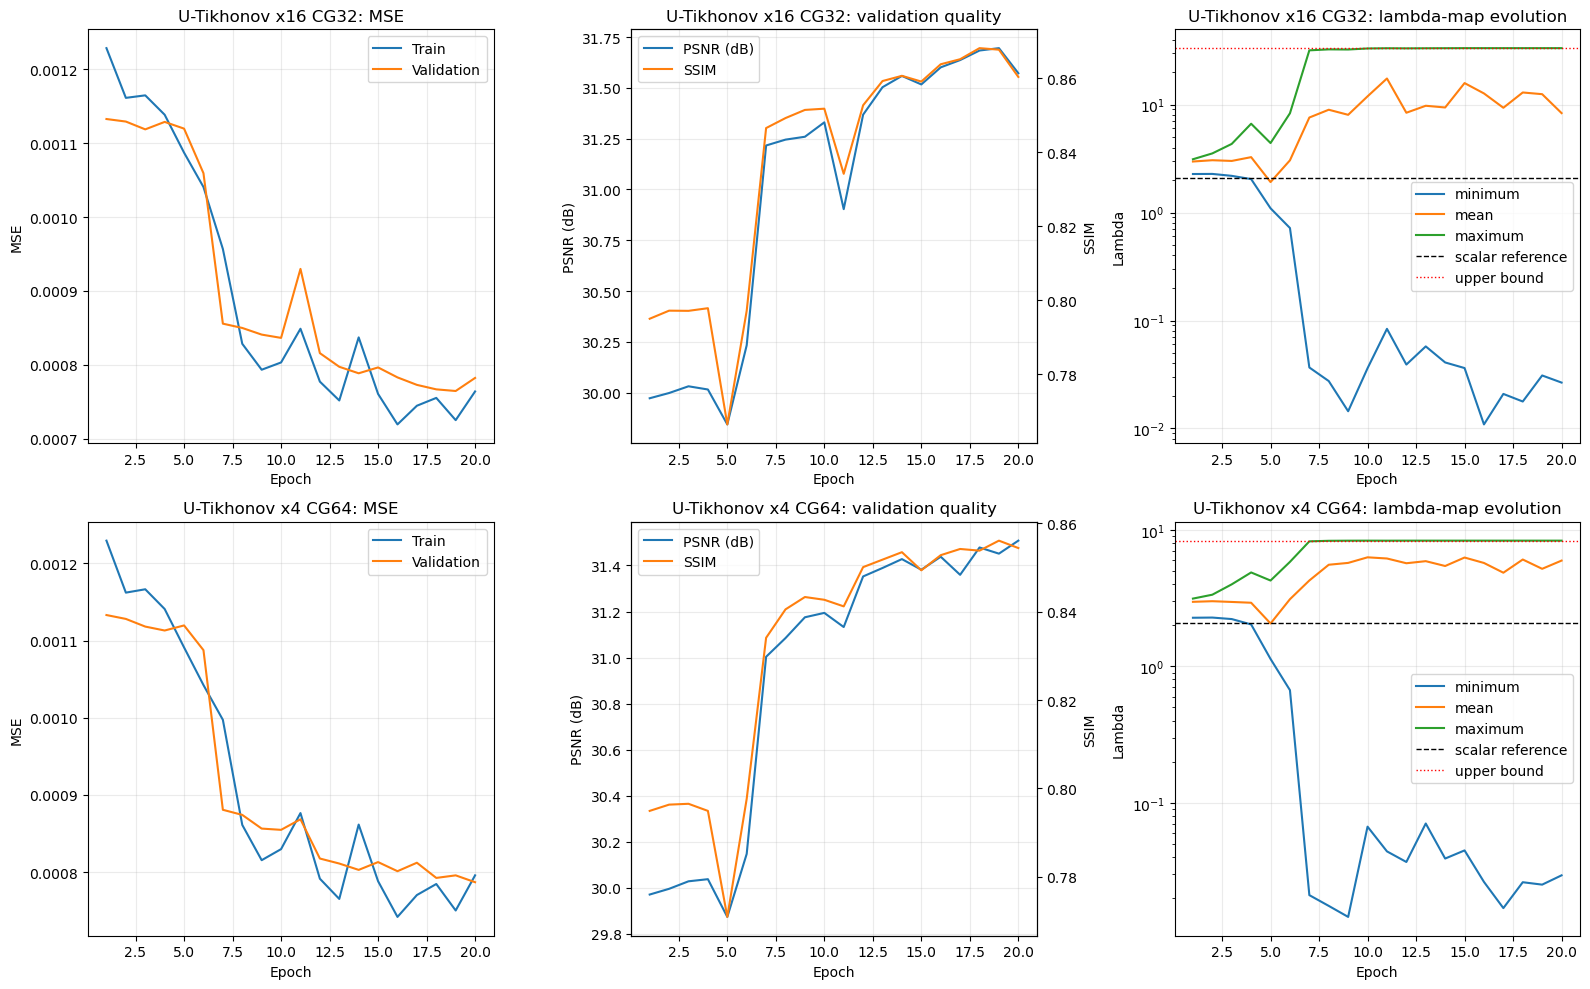

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/u_tikhonov_missing_ablation_training.png


In [7]:
figure, axes = plt.subplots(
    len(EXPERIMENTS),
    3,
    figsize=(16, 5 * len(EXPERIMENTS)),
    squeeze=False,
)

for row, (method, spec) in enumerate(EXPERIMENTS.items()):
    history = run_histories[method]
    if not isinstance(history, pd.DataFrame):
        history = pd.DataFrame(history)
    lambda_cap = spec["lambda_multiplier"] * reference_lambda

    axes[row, 0].plot(
        history["epoch"],
        history["train_mse"],
        label="Train",
    )
    axes[row, 0].plot(
        history["epoch"],
        history["val_mse"],
        label="Validation",
    )
    axes[row, 0].set(
        title=f"{method}: MSE",
        xlabel="Epoch",
        ylabel="MSE",
    )
    axes[row, 0].legend()

    axes[row, 1].plot(
        history["epoch"],
        history["val_psnr"],
        label="PSNR (dB)",
    )
    ssim_axis = axes[row, 1].twinx()
    ssim_axis.plot(
        history["epoch"],
        history["val_ssim"],
        color="tab:orange",
        label="SSIM",
    )
    axes[row, 1].set(
        title=f"{method}: validation quality",
        xlabel="Epoch",
        ylabel="PSNR (dB)",
    )
    ssim_axis.set_ylabel("SSIM")
    lines = axes[row, 1].lines + ssim_axis.lines
    axes[row, 1].legend(
        lines,
        [line.get_label() for line in lines],
    )

    for column, label in (
        ("val_lambda_min", "minimum"),
        ("val_lambda_mean", "mean"),
        ("val_lambda_max", "maximum"),
    ):
        if column in history:
            axes[row, 2].plot(
                history["epoch"],
                history[column],
                label=label,
            )
    axes[row, 2].axhline(
        reference_lambda,
        color="black",
        linestyle="--",
        linewidth=1,
        label="scalar reference",
    )
    axes[row, 2].axhline(
        lambda_cap,
        color="red",
        linestyle=":",
        linewidth=1,
        label="upper bound",
    )
    axes[row, 2].set(
        title=f"{method}: lambda-map evolution",
        xlabel="Epoch",
        ylabel="Lambda",
    )
    axes[row, 2].set_yscale("log")
    axes[row, 2].legend()

for axis in axes.ravel():
    axis.grid(alpha=0.25)

figure.tight_layout()
figure_path = (
    PROJECT_ROOT
    / "results"
    / "training"
    / "u_tikhonov_missing_ablation_training.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)
print("Saved:", figure_path)


In [8]:
summary_rows = []
for method, spec in EXPERIMENTS.items():
    run_dir = PROJECT_ROOT / "checkpoints" / spec["run_name"]
    summary = pd.read_csv(
        run_dir / "training_summary.csv"
    ).iloc[0].to_dict()
    summary.update(
        {
            "method": method,
            "lambda_max_multiplier": spec[
                "lambda_multiplier"
            ],
            "lambda_max": (
                spec["lambda_multiplier"] * reference_lambda
            ),
            "cg_iterations": spec["cg_iters"],
        }
    )
    summary_rows.append(summary)

new_run_summaries = pd.DataFrame(summary_rows)
new_run_summaries.to_csv(
    PROJECT_ROOT
    / "results"
    / "training"
    / "u_tikhonov_missing_ablation_training_summary.csv",
    index=False,
)
display(new_run_summaries)


,model_name,device,device_description,torch_version,parameter_count,epochs,training_images,validation_images,best_epoch,best_val_psnr,total_time_sec,mean_epoch_time_sec,mean_train_phase_time_sec,mean_validation_time_sec,mean_train_images_per_sec,solver_iterations,method,lambda_max_multiplier,lambda_max,cg_iterations
0,u_tikhonov,mps,Apple Metal Performance Shaders (MPS),2.12.0,1925025,20,500,50,19,31.695676,1596.676155,79.751201,75.091671,4.659179,6.659082,32,U-Tikhonov x16 CG32,16.0,33.281341,32
1,u_tikhonov,mps,Apple Metal Performance Shaders (MPS),2.12.0,1925025,20,500,50,20,31.507893,2241.262417,111.983199,105.335275,6.647581,4.824743,64,U-Tikhonov x4 CG64,4.0,8.320335,64


## Post-training fixed-CG accuracy audit

For ten deterministic validation images, each unrolled output is
compared with a tightly converged CG solution using the *same*
learned lambda map. This separates reconstruction quality from
truncation error.


In [9]:
@torch.no_grad()
def audit_fixed_cg(
    model,
    loader,
    *,
    method,
    images=10,
    converged_max_iter=256,
    converged_tol=1e-8,
):
    rows = []
    for image_index, batch in enumerate(loader):
        if image_index >= images:
            break

        clean = batch["clean"].to(device)
        noisy = batch["noisy"].to(device)
        fixed, lambda_map = model(noisy)

        def operator(image):
            return weighted_tikhonov_operator(
                image,
                lambda_map,
            )

        converged, info = cg_solve_until_converged(
            A=operator,
            b=noisy,
            x0=noisy,
            max_iter=converged_max_iter,
            tol=converged_tol,
            check_spd=True,
        )

        fixed_norm = torch.linalg.vector_norm(
            fixed
        ).clamp_min(1e-12)
        noisy_norm = torch.linalg.vector_norm(
            noisy
        ).clamp_min(1e-12)
        fixed_residual = torch.linalg.vector_norm(
            operator(fixed) - noisy
        ) / noisy_norm
        solution_difference = torch.linalg.vector_norm(
            fixed - converged
        ) / fixed_norm

        fixed_scored = fixed.clamp(0.0, 1.0)
        converged_scored = converged.clamp(0.0, 1.0)
        rows.append(
            {
                "method": method,
                "image_index": image_index,
                "path": batch["path"][0],
                "fixed_cg_iters": model.cg_iters,
                "converged_cg_iters": info["num_iter"],
                "converged": info["converged"],
                "fixed_relative_residual": float(
                    fixed_residual
                ),
                "relative_solution_difference": float(
                    solution_difference
                ),
                "fixed_psnr": float(
                    batch_psnr(fixed_scored, clean)[0]
                ),
                "converged_psnr": float(
                    batch_psnr(converged_scored, clean)[0]
                ),
                "fixed_ssim": float(
                    batch_ssim(fixed_scored, clean)[0]
                ),
                "converged_ssim": float(
                    batch_ssim(converged_scored, clean)[0]
                ),
                "lambda_min": float(lambda_map.min()),
                "lambda_mean": float(lambda_map.mean()),
                "lambda_max": float(lambda_map.max()),
            }
        )
    return pd.DataFrame(rows)


audit_frames = []
for method, spec in EXPERIMENTS.items():
    audit = audit_fixed_cg(
        trained_models[method],
        run_loaders[method],
        method=method,
    )
    run_dir = PROJECT_ROOT / "checkpoints" / spec["run_name"]
    audit.to_csv(
        run_dir / "post_training_cg_audit.csv",
        index=False,
    )
    audit_frames.append(audit)

cg_audit = pd.concat(audit_frames, ignore_index=True)
display(cg_audit)
display(
    cg_audit.groupby("method")[
        [
            "fixed_relative_residual",
            "relative_solution_difference",
            "fixed_psnr",
            "converged_psnr",
            "fixed_ssim",
            "converged_ssim",
        ]
    ].agg(["mean", "max"])
)


,method,image_index,path,fixed_cg_iters,converged_cg_iters,converged,fixed_relative_residual,relative_solution_difference,fixed_psnr,converged_psnr,fixed_ssim,converged_ssim,lambda_min,lambda_mean,lambda_max
0,U-Tikhonov x16 CG32,0,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,32,151,False,0.022193,4.076981e-03,30.837639,30.796432,0.896385,0.895745,0.060470,15.597204,33.281338
1,U-Tikhonov x16 CG32,1,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,32,146,False,0.019173,3.372434e-03,26.063154,26.054058,0.747004,0.745871,0.145309,3.216884,32.973560
2,U-Tikhonov x16 CG32,2,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,32,99,False,0.001537,3.267406e-04,28.869270,28.865330,0.844886,0.844735,0.114201,2.540866,18.876822
3,U-Tikhonov x16 CG32,3,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,32,110,False,0.002066,4.153776e-04,32.561848,32.549587,0.840492,0.840140,0.255765,3.900630,24.142509
4,U-Tikhonov x16 CG32,4,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,32,149,False,0.016903,3.016487e-03,29.959116,29.936144,0.845681,0.844742,0.185442,7.163769,33.259632
5,U-Tikhonov x16 CG32,5,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,32,149,False,0.017362,3.131725e-03,28.832386,28.791691,0.849283,0.848549,0.026618,9.299742,33.208679
6,U-Tikhonov x16 CG32,6,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,32,148,False,0.015787,2.852295e-03,30.728497,30.688370,0.834544,0.833768,0.083176,8.468140,33.264568
7,U-Tikhonov x16 CG32,7,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,32,148,False,0.015554,2.848616e-03,30.983871,30.939398,0.882298,0.881116,0.191885,8.401176,33.240383
8,U-Tikhonov x16 CG32,8,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,32,115,False,0.002942,5.854138e-04,30.411528,30.400902,0.852243,0.851918,0.195022,3.420132,24.336557
9,U-Tikhonov x16 CG32,9,/Users/kyrillguba/.cache/kagglehub/datasets/wi...,32,95,False,0.001281,2.788597e-04,30.718597,30.715580,0.855918,0.855829,0.330692,2.890570,17.640326


fixed_relative_residual            \
                                       mean       max   
method                                                  
U-Tikhonov x16 CG32                0.011480  0.022193   
U-Tikhonov x4 CG64                 0.000004  0.000006   

                    relative_solution_difference               fixed_psnr  \
                                            mean           max       mean   
method                                                                      
U-Tikhonov x16 CG32                 2.090493e-03  4.076981e-03  29.996591   
U-Tikhonov x4 CG64                  3.764349e-09  6.417018e-09  30.064019   

                               converged_psnr            fixed_ssim            \
                           max           mean        max       mean       max   
method                                                                          
U-Tikhonov x16 CG32  32.561848      29.973749  32.549587   0.844873  0.896385   
U-Tikhonov x4 CG64   33.198982      30.064019  33.198982   0.846749  0.882947   

                    converged_ssim            
                              mean       max  
method                                        
U-Tikhonov x16 CG32       0.844241  0.895745  
U-Tikhonov x4 CG64        0.846750  0.882946